이전에 [데이터 기초](./2026-05-22_data_analysis_basic.ipynb) 를 2026-05-22 04시쯤에 했고

현재 2026-05-22 21:30 에 복습 한 뒤 다음 단계 (히스토그램, 시각화 등)으로 넘어가려 한다.

In [2]:
import pandas as pd
import numpy as nd

data = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 900])



print(f"mean: {data.mean()}")
print(f"median: {data.median()}")
print(f"std: {data.std(ddof=1)}")

q1 = data.quantile(0.25)
q2 = data.quantile(0.5)
q3 = data.quantile(0.75)
print(f"q1: {q1}")
print(f"q2: {q2}")
print(f"q3: {q3}")

iqr = q3-q1
print(f"iqr: {iqr}")
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"lower_bound: {lower_bound}")
print(f"upper_bound: {upper_bound}")

print(f"outliner: {data[(data < lower_bound ) | (data > upper_bound)]}")


mean: 140.0
median: 50.0
std: 285.9195691099159
q1: 30.0
q2: 50.0
q3: 70.0
iqr: 40.0
lower_bound: -30.0
upper_bound: 130.0
outliner: 8    900
dtype: int64


평균값이 140인 데이터가 있다. 이는 중앙값이 50이지만 outliner이 900인 값이 하나가 존재하기 때문이다. 이때문에 분산이 약285가 되어있었다.

---

# 분포와 시각화
이것은 이론보다는 숫자로 요약한 데이터 상태를 그림으로 보고 해석하는 감각을 기르는 작업입니다.
이를 통해서 너무 많은 데이터 셋을 한눈에 확인 가능한 데이터 셋으로 만들어서 한눈에 데이터의 상태를 확인 가능하게 됩니다.

In [2]:
try:
    import pandas as pd
except ImportError:
    pass

scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]

s = pd.Series(scores)

# 기본 통계
print(s.describe())

count     20.000000
mean      76.100000
std       23.208211
min       45.000000
25%       61.500000
50%       73.500000
75%       85.750000
max      150.000000
dtype: float64


1. 평균은 얼마인가?
- 76.1
2. 중앙값은 얼마인가?
- 73
3. 평균이 중앙값보다 큰 이유는 무엇인가?
- 중앙값을 기준으로 더 큰 수들의 편차 제곱의 합이 더 커서. (더 멀리 퍼져 있어서)
4. 표준편차가 커진 이유는 무엇인가?
- 중앙값 기준 더 큰 값들이 더 멀리 존재해서
5. 이 데이터에서 의심되는 이상치는 무엇인가?
- q3이 85.75인데 150으로 존재하는 max

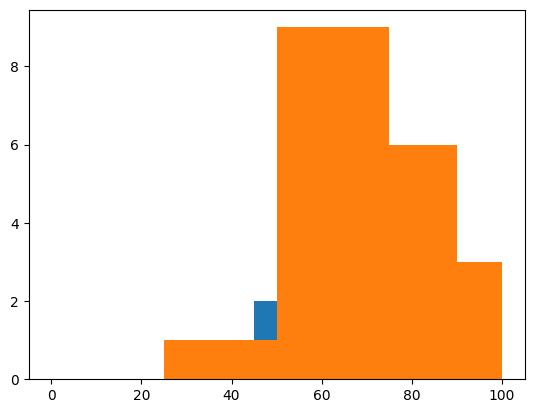

In [ ]:
# 데이터 시각화 라이브러리 matplotlib
# 그중에서 파이썬에서 그래프를 그리는 대표 라이브러리 pyplot
import matplotlib.pyplot as plt

scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]

# (데이터 셋, 
# plt.hist(s, bins=10)
plt.hist(s, bins=[0, 25, 50, 75, 90, 100])
# 45 ~ 110 까지 데이터가 1~4개 존재하며 140 이상에 하나 존재
plt.show()

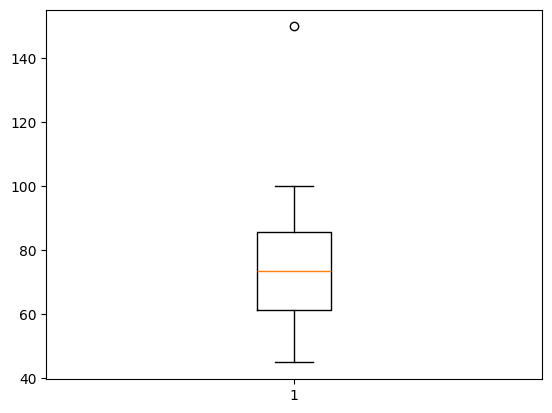

In [6]:
# 박스플롯
# 사분위수, IQR, 이상치를 한번에 보여주는 그래프
plt.boxplot(s)
plt.show()
# 이상치가 하나 존재하는 모습을 확인 가능. 
# 약 q1: 60초반, q2: 70쯤, q3: 85쯤

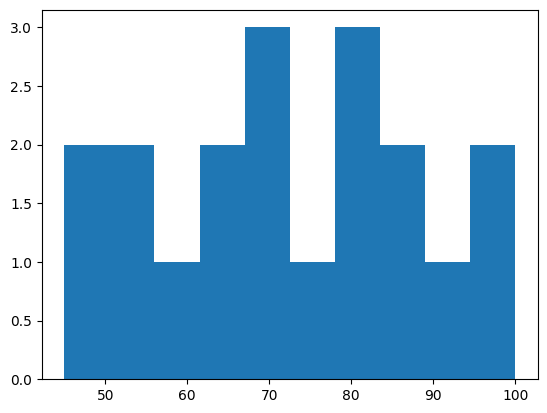

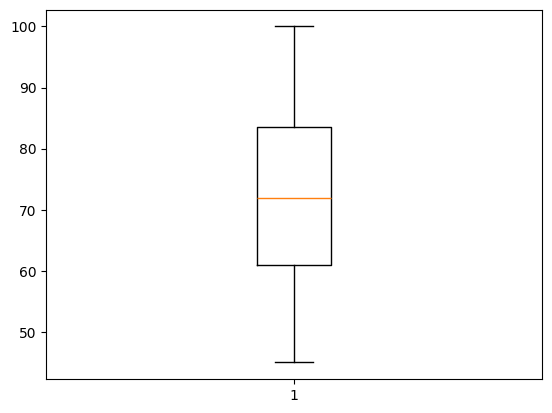

In [ ]:
# 데이터 시각화 라이브러리
try:
    import matplotlib.pyplot as plt
except ImportError:
    pass
    
# 이상치 제거
scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100,]

s = pd.Series(scores)

# 히스토그램
plt.hist(s, bins=10)
plt.show()
# 박스플롯
plt.boxplot(s)
plt.show()

# 좀 더 골고루 나누어지는 모습